In [1]:
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from sklearn.datasets import  load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVC

# Support Vector Machines

Support Vector Machines (SVMs) are machine learning models commonly used for binary classification. Let us first assume that the dataset is linearly separable. Given a dataset with samples $x_j \in \mathbb{R}^n$ and labels $y_j \in {-1,1}$, the objective of an SVM is to find a separating hyperplane

$$
H = \{x \in \mathbb{R}^n : \vec{w}\cdot \vec{x}+b=0\}
$$

where $\vec{w} \in \mathbb{R}^n$ is the normal vector to the hyperplane and $b \in \mathbb{R}$ is the bias term.

The decision rule is based on the sign of

$$
f(x)=\vec{w}\cdot \vec{x}+b
$$

If $f(x)>0$, the sample is assigned to class $+1$, whereas if $f(x)<0$, it is assigned to class $-1$. Points satisfying $f(x)=0$ lie exactly on the decision boundary, so their classification is ambiguous unless a specific convention is chosen.

First, let's consider the hard-margin SVMs, where no elements of the dataset are allowed to be inside the margin and therefore, none are misclassified. Consequently, training samples are constrained to satisfy:

$$
y_j(\vec{w}\cdot \vec{x}_j+b) \geq 1
$$

Therefore, the closest training samples do not lie on the separating hyperplane $f(x)=0$, but on the margin hyperplanes

$$
\vec{w}\cdot \vec{x}+b = 1
$$

and

$$
\vec{w}\cdot \vec{x}+b = -1
$$

These closest samples are called support vectors. In this particular case, the training  SVMs can be written as the following optimization problem:

$$
\begin{aligned}
\text{Minimize} \quad & \frac{1}{2}||w||^2 
\end{aligned}
$$
$$
\begin{aligned}
\text{subject to} \quad & y_j(\vec{w}\cdot \vec{x_j} + b) \geq 1
\end{aligned}
$$

If constrast, soft-margin SVMs admit some tolerance introduced by some parameters $\xi_j \geq0$. The optimization problem for the training of soft-margin SVMs can be expressed as:

$$
\begin{aligned}
\text{Minimize} \quad & \frac{1}{2}||w||^2 + C\sum_j \xi_j 
\end{aligned}
$$
$$
\begin{aligned}
\text{subject to} \quad & y_j(\vec{w}\cdot \vec{x_j} + b) \geq 1 - \xi_j, \quad & \xi_j \geq 0 
\end{aligned}
$$

Here, $C>0$ is a hyperparameter that quantifies how tolerant we are to training examples falling inside the margin or even to be missclassified. The bigger the value of $C$, the closest the model will be to the hard-margin case. The soft-margin case can be equivalently written in terms of some optimizable parameters $\alpha_j$ as:

$$
\begin{aligned}
\text{Minimize} \quad & \sum_j \alpha_j - \frac{1}{2}\sum_{j,k}y_j y_k \alpha_j \alpha_k (\vec{x_j}\cdot \vec{x_k})
\end{aligned}
$$
$$
\begin{aligned}
\text{subject to} \quad & \sum_j \alpha_j y_j = 0 , \quad & 0 \leq \alpha_j \leq C
\end{aligned}
$$

The relation between these to formulations can be shown to be:

$$
\vec{w} = \sum_j \alpha_j y_j \vec{x_j}
$$

And $b$ can be recovered by finding some $\vec{x_j}$ that lies at the margin and solving a simple ecuation. Given that, we can classify points by computing:

$$
f(x)=\vec{w}\cdot \vec{x}+b = \sum_j \alpha_j y_j (\vec{x_j}\cdot \vec{x})+b
$$

and checking the sign of the result values, exactly as before. Notice that, in this formulation, $\vec{w}$ only depends on the points $\vec{x_j}$ for which $\alpha_j \neq 0$. Those vectors are called the support vectors.

# The kernel trick



Considering only linearly separable data results in a very limited model that is not of much practical interest. To overcome this limitation, we will use the kernel trick, which is a technique that maps the original data from its original space $\mathbb{R}^n$ to a higher dimensional space $\mathbb{R}^N$ called feature space. The reason for this mapping is that we hope that the data will be separable by a hyperplane in the feature space. In order to perform the mapping, we will use the function:

$$
\phi: \mathbb{R}^n \rightarrow \mathbb{R}^N 
$$

known as feature map.

In order to train SVMs and to classify data, we don't need to know the exact form of the feature map, we only need to be able to compute scalar products of elements returned by the feature map. The reason for this, is that in both training and classification processes, the only operation that depends on the $\vec{x_j}$ points is the inner product $\vec{x_j}\cdot\vec{x_k}$ when training, or $\vec{x_j}\cdot\vec{x}$ when classifying $\vec{x}$. That way, we just need to be able to compute functions of the form:

$$
k(x,y) = \phi (\vec{x})\cdot\phi (\vec{y})
$$

known as kenel functions.

# Quantum Support Vector Machines

Quantum Support Vector Machines (QSVMs) are a variant of SVMs in which classical data are mapped into a quantum feature space, represented by states in a Hilbert space. This way, we will follow tha steps explained before except for the computation of the kernel function, that will be performed by a quantum computer. Given a feature map $\phi$, we will implement it with a circuit  that will depend on some classical data in the original space $C(\vec{x})$. Consequently, for each input $\vec{x}$, will result on a quantum state after applying the circuit:

$$
|\psi(\vec{x}) \rangle=  C(\vec{x})|0\rangle
$$

Thus, our kernel function can be exrpessed as:

$$
k(\vec{x}, \vec{y})
= 
\left |\langle \psi(\vec{x})|\psi(\vec{y}) \rangle \right |^2
=
\left | \langle 0 | \phi^\dagger (\vec{x}) \phi (\vec{y}) | 0 \rangle \right |^2
$$

Which can be computed by estimating the probability of measuring $|0\rangle$ after preparing the state $\phi^\dagger (\vec{x}) \phi (\vec{y}) | 0 \rangle$.


# Dataset

We will use a real dataset with information about wined using the `load_wine` function imported from `sklearn.datasets`.

In [2]:
SEED = 42 # For repodicibility

# Load the data
x, y = load_wine(return_X_y=True)

# Keep only 2 labels for binary classification
x = x[:59+71]
y = y[:59+71]

# Split into train and test
x_tr, x_test, y_tr, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=SEED) 

# Normalization of the data
scaler = MaxAbsScaler()

x_tr = scaler.fit_transform(x_tr)
x_test = scaler.transform(x_test)
x_test = np.clip(x_test, 0, 1)

# Get info about the dataset

print(f"The dataset contains {x_tr.shape[0]} rows with {x_tr.shape[1]} features")

The dataset contains 117 rows with 13 features


# QSVMs using PennyLane

First, will use amplitude encoding with 4 qubits in order to fit the 13 variables of the dataset.

In [ ]:
nqubits = 4
dev = qml.device("lightning.qubit", wires = nqubits)

@qml.qnode(dev)
def kernel_ampl_emb(a, b):
    """
    Computes the probability distribution associated with the overlap between
    two quantum states encoded with amplitude embedding.
    """
    # Encode the first classical vector into a quantum state
    qml.AmplitudeEmbedding(
        features=a,
        wires=range(nqubits),
        pad_with=0, # We use padding sice we have 13 features and 2^4=16 params
        normalize=True
    )
    # Apply the inverse embedding of the second vector
    qml.adjoint(qml.AmplitudeEmbedding(
        features=b,
        wires=range(nqubits),
        pad_with=0,
        normalize=True
    ))
    
    # Return probabilities for all basis states
    return qml.probs(wires=range(nqubits))

def qkernel_ampl(A, B):
    """
    Computes the quantum kernel matrix between two datasets using amplitude embedding.
    """
    return np.array([[kernel_ampl_emb(a, b)[0] for b in B] for a in A])

# Train a classical SVM using the custom quantum kernel
svm_ampl = SVC(kernel = qkernel_ampl).fit(x_tr, y_tr)

# Compute classification accuracy
acc_ampl = accuracy_score(svm_ampl.predict(x_test), y_test)
print(f"Accuracy score using amplitude encoding: {100*acc_ampl:.2f} %")

Accuracy score using amplitude encoding: 92.31 %


Now let's reduce out dataset to 8 features using PCA and use angle encoding instead.

In [4]:
pca = PCA(n_components=8)
xs_tr = pca.fit_transform(x_tr)
xs_test = pca.transform(x_test)

In [5]:
nqubits = 8
dev = qml.device("lightning.qubit", wires=nqubits)

@qml.qnode(dev)
def kernel_angle_emb(a, b):
    """
    Computes the probability distribution associated with the overlap between
    two quantum states encoded with angle embedding.
    """
    # Encode the first classical vector into a quantum state
    qml.AngleEmbedding(
        features=a,
        wires=range(nqubits)
    )
    # Apply the inverse embedding of the second vector
    qml.adjoint(qml.AngleEmbedding(
        features=b,
        wires=range(nqubits)
    ))

    # Return probabilities for all basis states
    return qml.probs(wires=range(nqubits))

def qkernel_angle(A, B):
    """
    Computes the quantum kernel matrix between two datasets using angle embedding.
    """
    return np.array([[kernel_angle_emb(a, b)[0] for b in B] for a in A])

# Train a classical SVM using the custom quantum kernel
svm_angle = SVC(kernel = qkernel_angle).fit(xs_tr, y_tr)
# Compute classification accuracy

# Compute classification accuracy
acc_angle = accuracy_score(svm_angle.predict(xs_test), y_test)
print(f"Accuracy score using angle encoding with PCA: {100* acc_angle:.2f} %")

Accuracy score using angle encoding with PCA: 100.00 %


# QSVMs using Qiskit

Using qiskit we can easily train QSVMs and test their performance. We'll simply use the `QSVC`class with a `FidelityQuantumKernel` object as argument. For the fidelity, we will use the `ComputeUncompute` class, that estimates the probability of measuring $|0\rangle$ after preparing the state $\phi^\dagger (\vec{x}) \phi (\vec{y}) | 0 \rangle$.

In [6]:
# Define the quantum feature map to encode classical data into quantum states
zz_fm = zz_feature_map(feature_dimension=8).decompose()

# Set up the fidelity measurement strategy
fidelity = ComputeUncompute(sampler=Sampler())

# Create the quantum kernel using the fidelity metric and the feature map
qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=zz_fm)

# Initialize the Quantum Support Vector Classifier with the quantum kernel
qsvm = QSVC(quantum_kernel=qkernel)

# Train the model on the training dataset
qsvm.fit(xs_tr, y_tr)

# Predict test labels and print the final accuracy score
acc = accuracy_score(qsvm.predict(xs_test), y_test)
print(f"Accuracy score using zz_feature_map with qiskit: {100*acc:.2f} %")

Accuracy score using zz_feature_map with qiskit: 76.92 %


Finally, we can visualize the pairwise quantum kernel matrix.

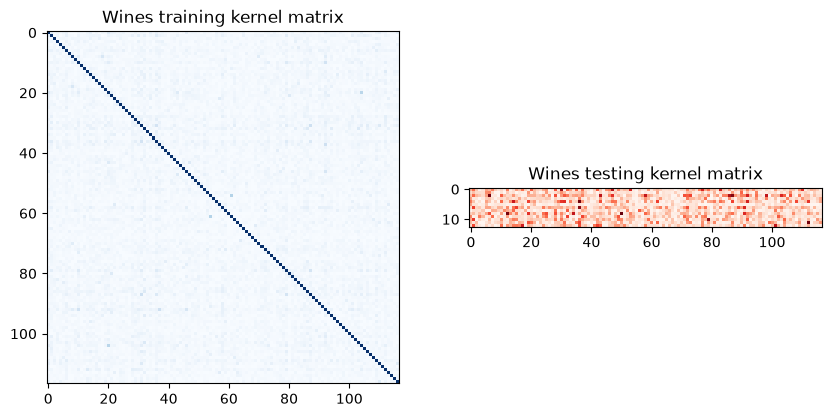

In [7]:
# Evaluate the pairwise quantum kernel matrix for the training data
matrix_train_wines = qkernel.evaluate(x_vec=xs_tr)
# Evaluate the quantum kernel matrix between the test data and the training data
matrix_test_wines = qkernel.evaluate(x_vec=xs_test, y_vec=xs_tr)

# Plot both matrices
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(
    np.asmatrix(matrix_train_wines), interpolation="nearest", origin="upper", cmap="Blues"
)
axs[0].set_title("Wines training kernel matrix")

axs[1].imshow(np.asmatrix(matrix_test_wines), interpolation="nearest", origin="upper", cmap="Reds")
axs[1].set_title("Wines testing kernel matrix")

plt.show()